# Bayesian Confidence Scoring — Orbitrap HILIC negESI
## Model Report

**Dataset:** Oliver's manually reviewed Orbitrap HILIC negESI spreadsheet (2026-03-19)  
**Pipeline:** `code/orbitrap_mvp.ipynb`  
**Outputs:** `results/orbitrap_mvp/assertions.csv`, `results/orbitrap_mvp/top_calls.csv`

---

### Problem

Given an LC-MS/MS spectrum matched against a spectral library, how confidently can we identify the compound? The naive approach — picking the highest entropy similarity hit — sets the baseline. This report evaluates a 4-channel Bayesian model against that baseline.

### Definition of TP and FP

The TP set is Oliver's manually re-annotated set (up to row 1298 as of 31. Marz). Every spectrum in this range has been reviewed and the compound name is believed to be correct.    

The FP set is spectra that were once annotated but flagged as suspicious during Oliver's review. Three distinct subtypes visible in the names starting with yy_ with comments. 

The TN set are zz_ entries, and those are believed as not a real spectra (possibly a spectra quality indicator?)

### Model Architecture

A two tier structure was deployed. 

In the first layer we ask the question: "is this a spectra that reveals a real compound rather than some artifact (for example, in void volumn, or a really bad eic peak). "zz_" are Layer 1 TNs — they fail before identification even begins (the spectrum itself is not real). And they don't contribute meaningfully to model fitting. The TN class in the wild (the full unlabeled set) is expected to be much larger. 

In the second layer we ask the question: "is this the real annotation?" based on 4 channels of evidence outlined below.

For each candidate hit, four independent log-likelihood ratios (LRs) are computed and combined multiplicatively before softmax normalisation into a posterior probability:

| Channel | Evidence | TP model | FP model |
|---|---|---|---|
| **MS2** | Entropy similarity | KDE on confirmed hits, entropy-weighted λ(H)=1−e^(−αH) | KDE on incorrect hits |
| **MS1** | Precursor mass error (ppm) | Gaussian, σ fitted from data | Broad Gaussian, σ=10 ppm |
| **RT** | Retention time deviation (s) | Gaussian, σ fitted per source | Broad Gaussian, σ=300 s |
| **sim_gap** | Gap to next-ranked hit | KDE on log1p(gap) for correct hits | KDE on log1p(gap) for incorrect hits |

A PubMed/patent prior (via CTS-lite API) provides a compound-level weight. A NoTA (No Target Available) hypothesis allows abstention when no candidate is credible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})

top_calls  = pd.read_csv('../results/orbitrap_mvp/top_calls.csv')
assertions = pd.read_csv('../results/orbitrap_mvp/assertions.csv')
print(f'top_calls:  {top_calls.shape}')
print(f'assertions: {assertions.shape}')


top_calls:  (1513, 32)
assertions: (9060, 34)


## 1. Dataset Overview

posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


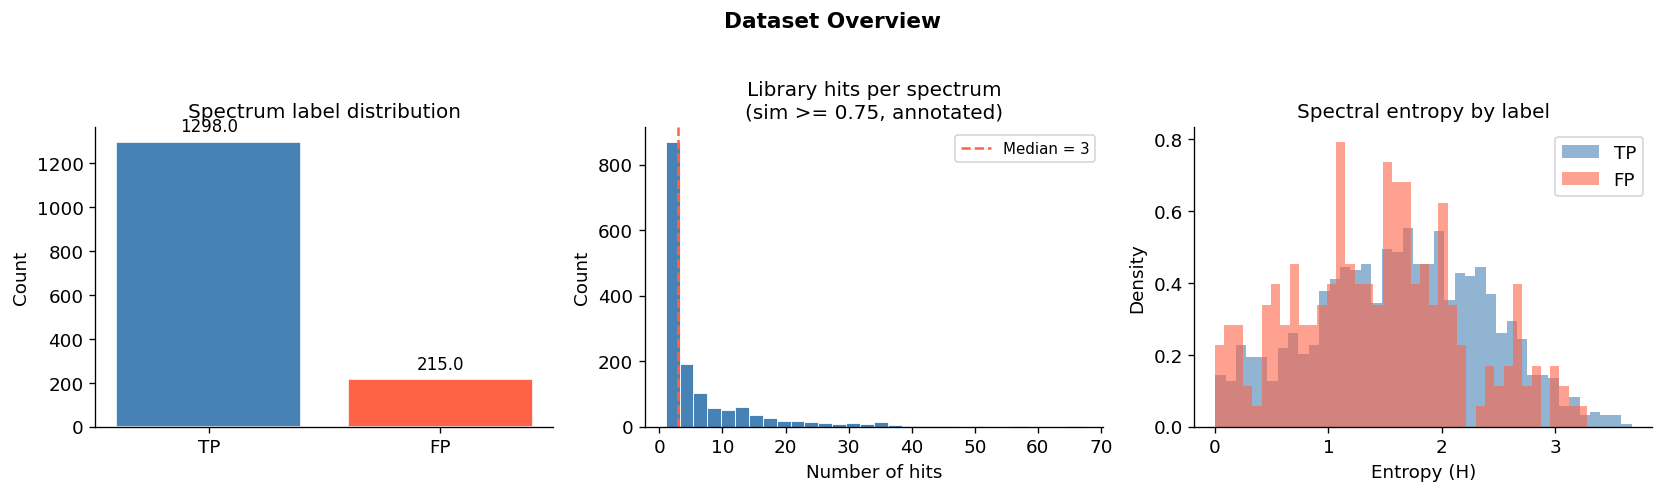

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Label distribution
lbl_counts = top_calls['label'].value_counts().reindex(['TP','FP','unlabeled'])
colors = ['steelblue', 'tomato', 'lightgrey']
axes[0].bar(lbl_counts.index, lbl_counts.values, color=colors, edgecolor='white')
for i, (lbl, cnt) in enumerate(lbl_counts.items()):
    axes[0].text(i, cnt + 30, str(cnt), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Spectrum label distribution')
axes[0].set_ylabel('Count')

# Hits per spectrum (annotated)
ann = assertions[assertions['label'].isin(['TP','FP'])]
hits_per = ann.groupby('wiki_id').size()
axes[1].hist(hits_per, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].axvline(hits_per.median(), color='tomato', ls='--', lw=1.5,
                label=f'Median = {hits_per.median():.0f}')
axes[1].set_title('Library hits per spectrum\n(sim >= 0.75, annotated)')
axes[1].set_xlabel('Number of hits'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

# Entropy distribution
for lbl, color in [('TP','steelblue'), ('FP','tomato')]:
    vals = top_calls[top_calls['label']==lbl]['obs_entropy'].dropna()
    axes[2].hist(vals, bins=40, density=True, alpha=0.6, color=color, label=lbl)
axes[2].set_title('Spectral entropy by label')
axes[2].set_xlabel('Entropy (H)'); axes[2].set_ylabel('Density')
axes[2].legend()

plt.suptitle('Dataset Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/report_01_dataset.png', bbox_inches='tight')
plt.show()


**Training set:** 1,186 TP spectra (rows 0–1297 of Oliver's spreadsheet, re-annotated minus the "golden" TP set (labelled in yellow)) + 215 FP spectra (yy_ prefix).  
**Test set (held-out):** 112 solid TP spectra (yellow/orange colour-coded by Oliver — highest-confidence ground truth, never seen during fitting).  
**Unlabeled:** 4,456 spectra (normal names after row 1298) — not yet re-reviewed, excluded from evaluation.


## 2. Evidence Channels

### 2a. MS2 — Entropy Similarity

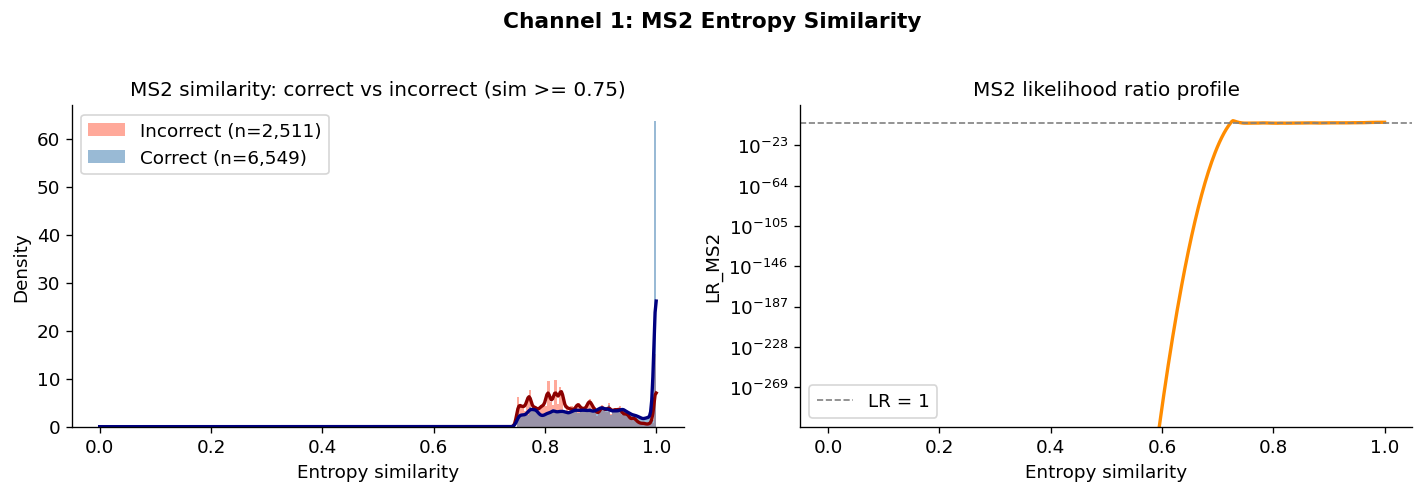

Correct:   mean=0.904  median=0.909
Incorrect: mean=0.857  median=0.845


In [3]:
correct   = assertions[assertions['correct']==True]['entropy_similarity'].dropna().values
incorrect = assertions[assertions['correct']==False]['entropy_similarity'].dropna().values
sim_grid  = np.linspace(0.0, 1.0, 500)
kde_tp = gaussian_kde(correct,   bw_method=0.05)
kde_fp = gaussian_kde(incorrect, bw_method=0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(incorrect, bins=60, density=True, alpha=0.55, color='tomato',
             label=f'Incorrect (n={len(incorrect):,})')
axes[0].hist(correct,   bins=60, density=True, alpha=0.55, color='steelblue',
             label=f'Correct (n={len(correct):,})')
axes[0].plot(sim_grid, kde_fp(sim_grid), color='darkred', lw=2)
axes[0].plot(sim_grid, kde_tp(sim_grid), color='navy',    lw=2)
axes[0].set_xlabel('Entropy similarity'); axes[0].set_ylabel('Density')
axes[0].set_title('MS2 similarity: correct vs incorrect (sim >= 0.75)')
axes[0].legend()

lr_ms2 = np.clip(kde_tp(sim_grid) / (kde_fp(sim_grid) + 1e-10), 0, 1000)
axes[1].plot(sim_grid, lr_ms2, color='darkorange', lw=2)
axes[1].axhline(1.0, color='grey', ls='--', lw=1, label='LR = 1')
axes[1].set_xlabel('Entropy similarity'); axes[1].set_ylabel('LR_MS2')
axes[1].set_yscale('log'); axes[1].set_title('MS2 likelihood ratio profile')
axes[1].legend()

plt.suptitle('Channel 1: MS2 Entropy Similarity', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/report_02_ms2.png', bbox_inches='tight')
plt.show()
print(f'Correct:   mean={correct.mean():.3f}  median={np.median(correct):.3f}')
print(f'Incorrect: mean={incorrect.mean():.3f}  median={np.median(incorrect):.3f}')


### 2b. MS1 — Precursor Mass Accuracy

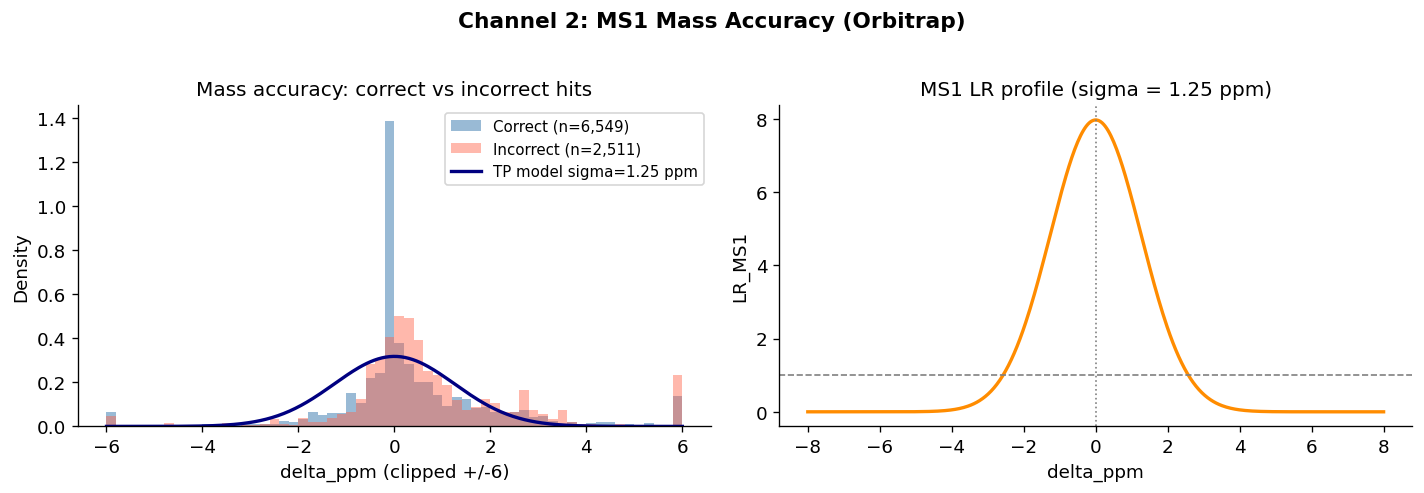

Correct delta_ppm: median=-0.000  IQR=[-0.183, 0.908]


In [4]:
ppm_c = assertions[assertions['correct']==True]['delta_ppm'].dropna()
ppm_i = assertions[assertions['correct']==False]['delta_ppm'].dropna()
sigma_M = 1.2538
ppm_x   = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ppm_c.clip(-6,6), bins=60, density=True, alpha=0.55,
             color='steelblue', label=f'Correct (n={len(ppm_c):,})')
axes[0].hist(ppm_i.clip(-6,6), bins=60, density=True, alpha=0.45,
             color='tomato',    label=f'Incorrect (n={len(ppm_i):,})')
axes[0].plot(ppm_x, norm.pdf(ppm_x, 0, sigma_M), color='navy', lw=2,
             label=f'TP model sigma={sigma_M:.2f} ppm')
axes[0].set_xlabel('delta_ppm (clipped +/-6)')
axes[0].set_ylabel('Density')
axes[0].set_title('Mass accuracy: correct vs incorrect hits')
axes[0].legend(fontsize=9)

ppm_range = np.linspace(-8, 8, 400)
lr_ms1 = norm.pdf(ppm_range, 0, sigma_M) / norm.pdf(ppm_range, 0, 10.0)
axes[1].plot(ppm_range, lr_ms1, color='darkorange', lw=2)
axes[1].axhline(1.0, color='grey', ls='--', lw=1)
axes[1].axvline(0, color='grey', ls=':', lw=1)
axes[1].set_xlabel('delta_ppm'); axes[1].set_ylabel('LR_MS1')
axes[1].set_title(f'MS1 LR profile (sigma = {sigma_M:.2f} ppm)')

plt.suptitle('Channel 2: MS1 Mass Accuracy (Orbitrap)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/report_03_ms1.png', bbox_inches='tight')
plt.show()
print(f'Correct delta_ppm: median={ppm_c.median():.3f}  IQR=[{ppm_c.quantile(.25):.3f}, {ppm_c.quantile(.75):.3f}]')


### 2c. sim_gap — Discrimination Power

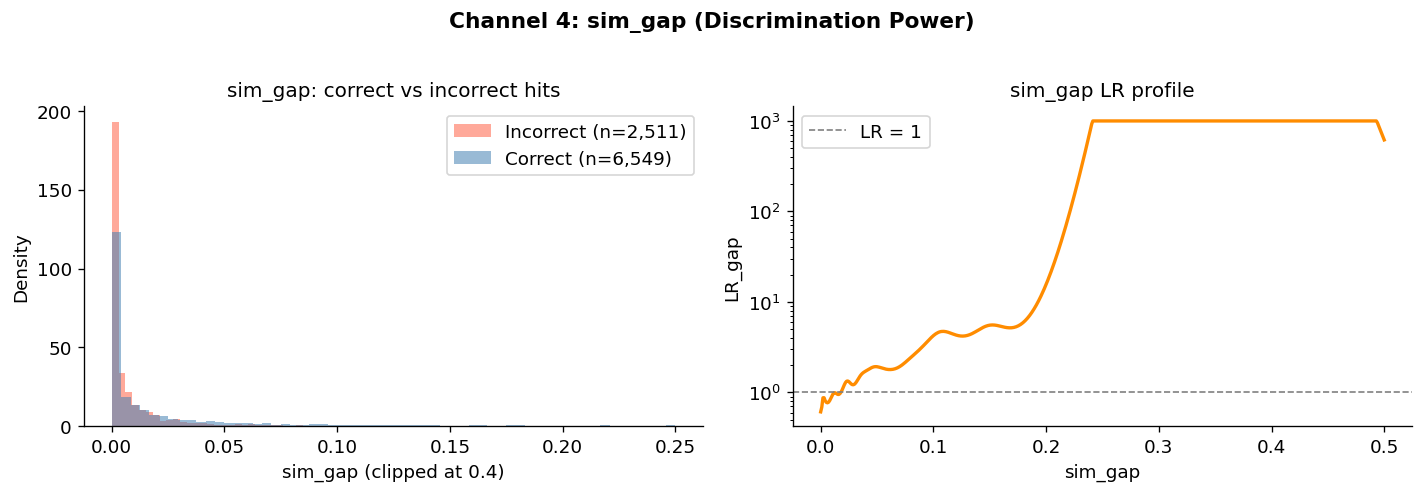

Correct:   mean=0.0258  >0.05: 16.1%
Incorrect: mean=0.0096  >0.05: 4.9%
Enrichment at >0.05: 3.3x


In [5]:
gap_c = assertions[assertions['correct']==True]['sim_gap'].fillna(0).values
gap_i = assertions[assertions['correct']==False]['sim_gap'].fillna(0).values
SCALE_GAP = 100.0
gap_grid  = np.linspace(0.0, 0.5, 500)
kde_gap_tp = gaussian_kde(np.log1p(gap_c * SCALE_GAP), bw_method=0.15)
kde_gap_fp = gaussian_kde(np.log1p(gap_i * SCALE_GAP), bw_method=0.15)
lr_gap = np.clip(
    kde_gap_tp(np.log1p(gap_grid * SCALE_GAP)) /
    (kde_gap_fp(np.log1p(gap_grid * SCALE_GAP)) + 1e-10), 0, 1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.clip(gap_i, 0, 0.4), bins=60, density=True, alpha=0.55,
             color='tomato',    label=f'Incorrect (n={len(gap_i):,})')
axes[0].hist(np.clip(gap_c, 0, 0.4), bins=60, density=True, alpha=0.55,
             color='steelblue', label=f'Correct (n={len(gap_c):,})')
axes[0].set_xlabel('sim_gap (clipped at 0.4)')
axes[0].set_ylabel('Density')
axes[0].set_title('sim_gap: correct vs incorrect hits')
axes[0].legend()

axes[1].plot(gap_grid, lr_gap, color='darkorange', lw=2)
axes[1].axhline(1.0, color='grey', ls='--', lw=1, label='LR = 1')
axes[1].set_xlabel('sim_gap'); axes[1].set_ylabel('LR_gap')
axes[1].set_yscale('log'); axes[1].set_title('sim_gap LR profile')
axes[1].legend()

plt.suptitle('Channel 4: sim_gap (Discrimination Power)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/report_04_simgap.png', bbox_inches='tight')
plt.show()
ratio = (gap_c > 0.05).mean() / (gap_i > 0.05).mean()
print(f'Correct:   mean={gap_c.mean():.4f}  >0.05: {(gap_c>0.05).mean():.1%}')
print(f'Incorrect: mean={gap_i.mean():.4f}  >0.05: {(gap_i>0.05).mean():.1%}')
print(f'Enrichment at >0.05: {ratio:.1f}x')


### 2d. Literature Prior (PubMed / Patent)

A literature prior is calculated as following:

prior = 0.5 × min(1, log1p(pubmed_count) / 6)
        + 0.5 × patent contribution

where patent contribution = min(1, log1p(patent_count) / 5).

A log transformation is used here because some of the compounds are so relavant that they would blow up this term (for example, glucose ~200000 pubmed)

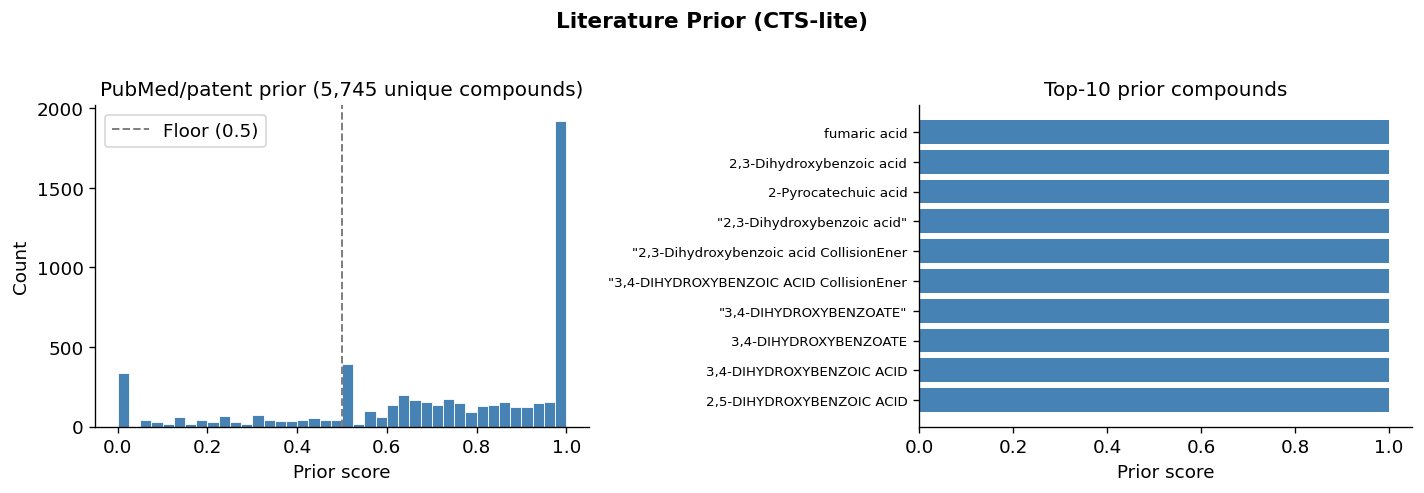

Non-floor: 75.0%  Mean: 0.721


In [6]:
prior_vals = assertions[['name','prior_score']].drop_duplicates('name').sort_values('prior_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prior_vals['prior_score'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(0.5, color='grey', ls='--', lw=1.2, label='Floor (0.5)')
axes[0].set_xlabel('Prior score'); axes[0].set_ylabel('Count')
axes[0].set_title(f'PubMed/patent prior ({len(prior_vals):,} unique compounds)')
axes[0].legend()

top10 = prior_vals.head(10)
axes[1].barh(range(len(top10)), top10['prior_score'].values, color='steelblue')
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels([n[:40] for n in top10['name'].values], fontsize=8)
axes[1].set_xlabel('Prior score'); axes[1].set_title('Top-10 prior compounds')
axes[1].invert_yaxis()

plt.suptitle('Literature Prior (CTS-lite)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/report_05_prior.png', bbox_inches='tight')
plt.show()
print(f'Non-floor: {(prior_vals["prior_score"]>0.5).mean():.1%}  Mean: {prior_vals["prior_score"].mean():.3f}')


## 3. Fitted Parameters (deprecated)

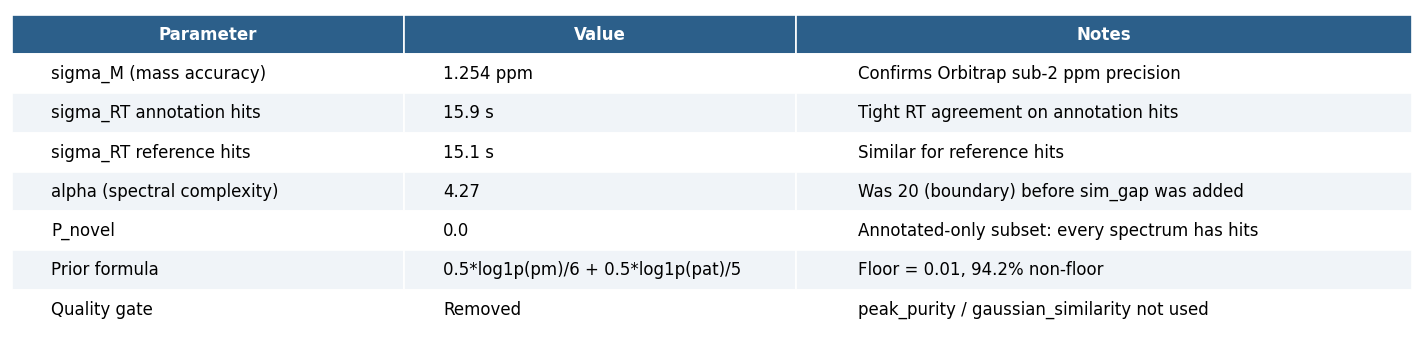

In [7]:
rows = [
    ['sigma_M (mass accuracy)',    '1.254 ppm',              'Confirms Orbitrap sub-2 ppm precision'],
    ['sigma_RT annotation hits',   '15.9 s',                 'Tight RT agreement on annotation hits'],
    ['sigma_RT reference hits',    '15.1 s',                 'Similar for reference hits'],
    ['alpha (spectral complexity)', '4.27',                  'Was 20 (boundary) before sim_gap was added'],
    ['P_novel',                    '0.0',                    'Annotated-only subset: every spectrum has hits'],
    ['Prior formula',              '0.5*log1p(pm)/6 + 0.5*log1p(pat)/5', 'Floor = 0.01, 94.2% non-floor'],
    ['Quality gate',               'Removed',                'peak_purity / gaussian_similarity not used'],
]

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
tbl = ax.table(cellText=rows, colLabels=['Parameter','Value','Notes'],
               cellLoc='left', loc='center', colWidths=[0.28, 0.28, 0.44])
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.7)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c5f8a'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f4f8')
    cell.set_edgecolor('white')
plt.tight_layout()
plt.savefig('../figures/report_06_params.png', bbox_inches='tight')
plt.show()


## 4. Performance

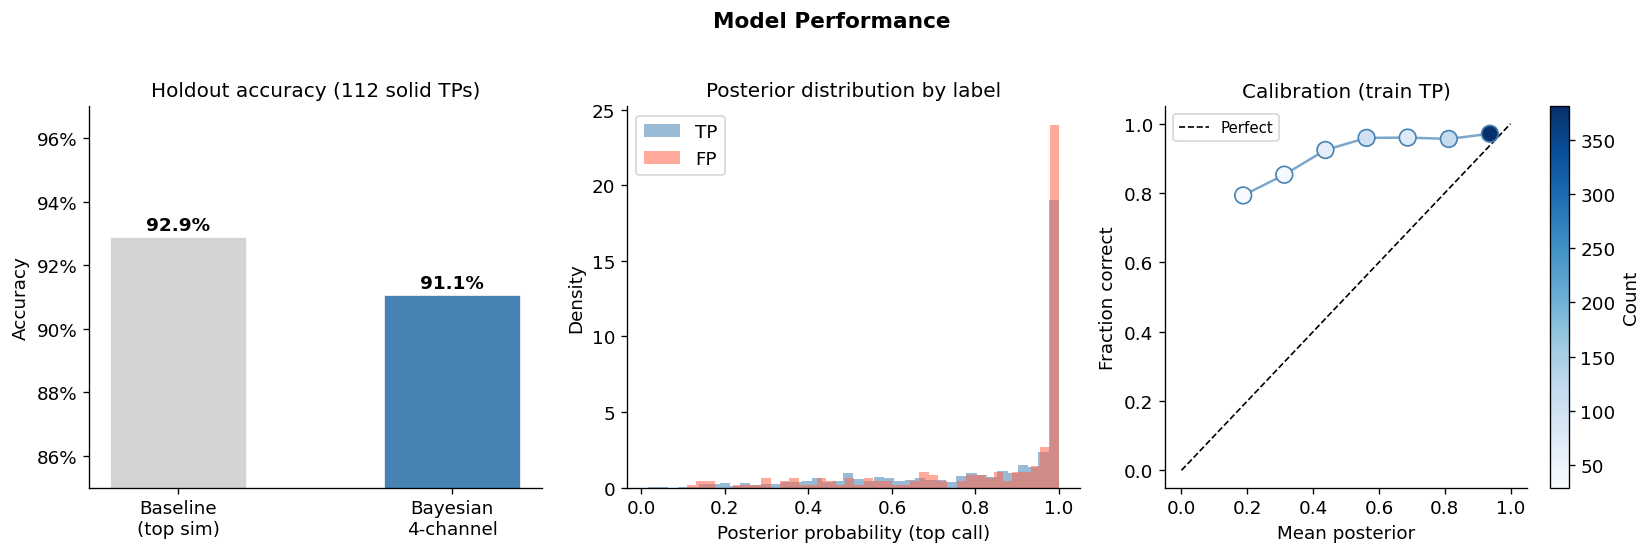

Baseline:        92.9%
Model accuracy:  91.1%  (102/112)
Mean posterior:  0.738


In [8]:
holdout  = top_calls[top_calls['holdout']].copy()
train_tp = top_calls[(top_calls['label']=='TP') & ~top_calls['holdout']].copy()

model_acc = (holdout['correct'] == True).mean()
baseline  = 0.929

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Accuracy bars
bars = axes[0].bar(['Baseline\n(top sim)', 'Bayesian\n4-channel'],
                   [baseline, model_acc], color=['lightgrey','steelblue'],
                   edgecolor='white', width=0.5)
axes[0].set_ylim(0.85, 0.97)
for bar, v in zip(bars, [baseline, model_acc]):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.002,
                 f'{v:.1%}', ha='center', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Holdout accuracy (112 solid TPs)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Posterior distribution by label
for lbl, color in [('TP','steelblue'), ('FP','tomato')]:
    vals = top_calls[top_calls['label']==lbl]['post_top'].dropna()
    axes[1].hist(vals, bins=40, density=True, alpha=0.55, color=color, label=lbl)
axes[1].set_xlabel('Posterior probability (top call)')
axes[1].set_ylabel('Density')
axes[1].set_title('Posterior distribution by label')
axes[1].legend()

# Calibration on train TP
cal = train_tp[train_tp['correct'].notna()].copy()
bins = np.linspace(0, 1, 9)
mids, fracs, counts = [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (cal['post_top'] >= lo) & (cal['post_top'] < hi)
    if m.sum() >= 5:
        mids.append((lo+hi)/2); fracs.append(cal.loc[m,'correct'].mean()); counts.append(m.sum())
axes[2].plot([0,1],[0,1], 'k--', lw=1, label='Perfect')
sc = axes[2].scatter(mids, fracs, c=counts, cmap='Blues', s=100, zorder=5,
                     edgecolors='steelblue', linewidths=1)
axes[2].plot(mids, fracs, color='steelblue', lw=1.5, alpha=0.7)
plt.colorbar(sc, ax=axes[2], label='Count')
axes[2].set_xlabel('Mean posterior'); axes[2].set_ylabel('Fraction correct')
axes[2].set_title('Calibration (train TP)'); axes[2].legend(fontsize=9)

plt.suptitle('Model Performance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/report_07_performance.png', bbox_inches='tight')
plt.show()
print(f'Baseline:        {baseline:.1%}')
print(f'Model accuracy:  {model_acc:.1%}  ({int(model_acc*112)}/112)')
print(f'Mean posterior:  {holdout["post_top"].mean():.3f}')


## 5. Error Analysis

Total misses:          10
InChIKey14 artifacts:  6  (correct name, wrong library stereoisomer entry)
Genuine wrong calls:   4
Effective accuracy:    96.4%  (108/112)


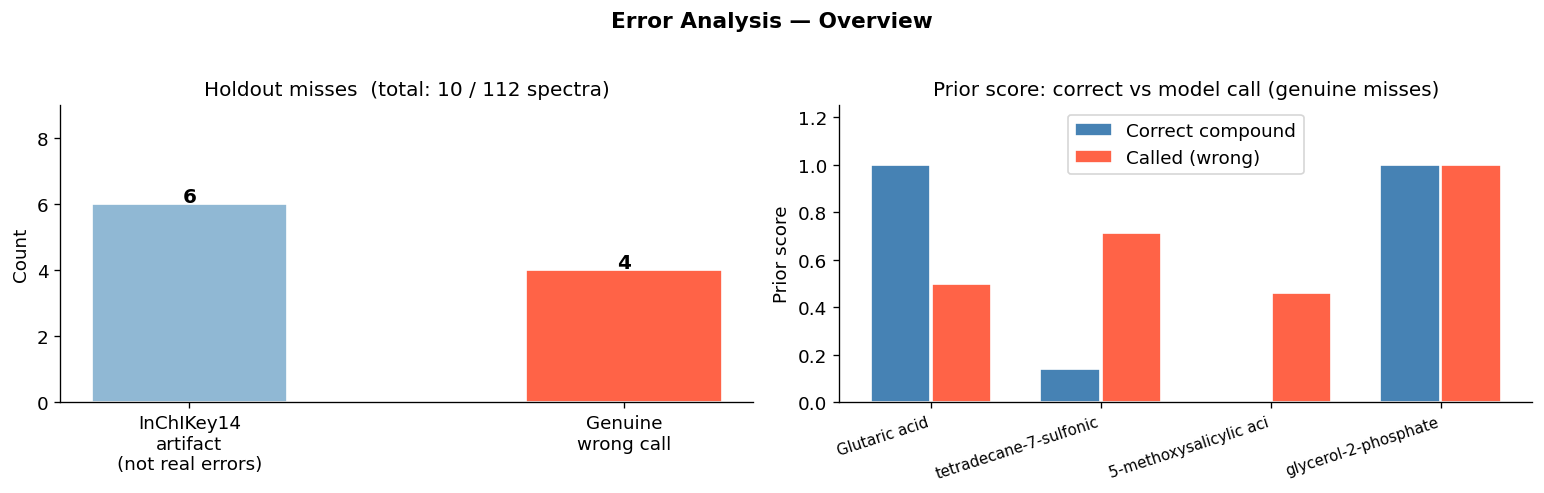

In [9]:
misses = holdout[holdout['correct']==False].copy()
misses['name_match'] = misses['anno_name'] == misses['lib_name_top']
genuine = misses[~misses['name_match']].copy()

print(f'Total misses:          {len(misses)}')
print(f'InChIKey14 artifacts:  {misses["name_match"].sum()}  (correct name, wrong library stereoisomer entry)')
print(f'Genuine wrong calls:   {(~misses["name_match"]).sum()}')
print(f'Effective accuracy:    {(112 - len(genuine)) / 112:.1%}  ({112-len(genuine)}/112)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Miss category breakdown
cats = ['InChIKey14\nartifact\n(not real errors)', 'Genuine\nwrong call']
vals = [misses['name_match'].sum(), (~misses['name_match']).sum()]
bars = axes[0].bar(cats, vals, color=['#90b8d4', 'tomato'], edgecolor='white', width=0.45)
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.08, str(v),
                 ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count'); axes[0].set_ylim(0, 9)
axes[0].set_title(f'Holdout misses  (total: {len(misses)} / 112 spectra)')

# Prior comparison for genuine misses
correct_priors, called_priors, case_lbls = [], [], []
for _, row in genuine.iterrows():
    wid = row['wiki_id']
    cr = assertions[(assertions['wiki_id']==wid) & (assertions['correct']==True)]
    wr = assertions[(assertions['wiki_id']==wid) & (assertions['name']==row['lib_name_top'])]
    if len(cr) and len(wr):
        correct_priors.append(cr['prior_score'].values[0])
        called_priors.append(wr['prior_score'].values[0])
        case_lbls.append(row['anno_name'][:22])
x = np.arange(len(case_lbls))
axes[1].bar(x-0.18, correct_priors, 0.35, label='Correct compound', color='steelblue', edgecolor='white')
axes[1].bar(x+0.18, called_priors,  0.35, label='Called (wrong)',   color='tomato',    edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(case_lbls, rotation=18, ha='right', fontsize=9)
axes[1].set_ylabel('Prior score')
axes[1].set_title('Prior score: correct vs model call (genuine misses)')
axes[1].legend(); axes[1].set_ylim(0, 1.25)

plt.suptitle('Error Analysis — Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/report_08_errors.png', bbox_inches='tight')
plt.show()


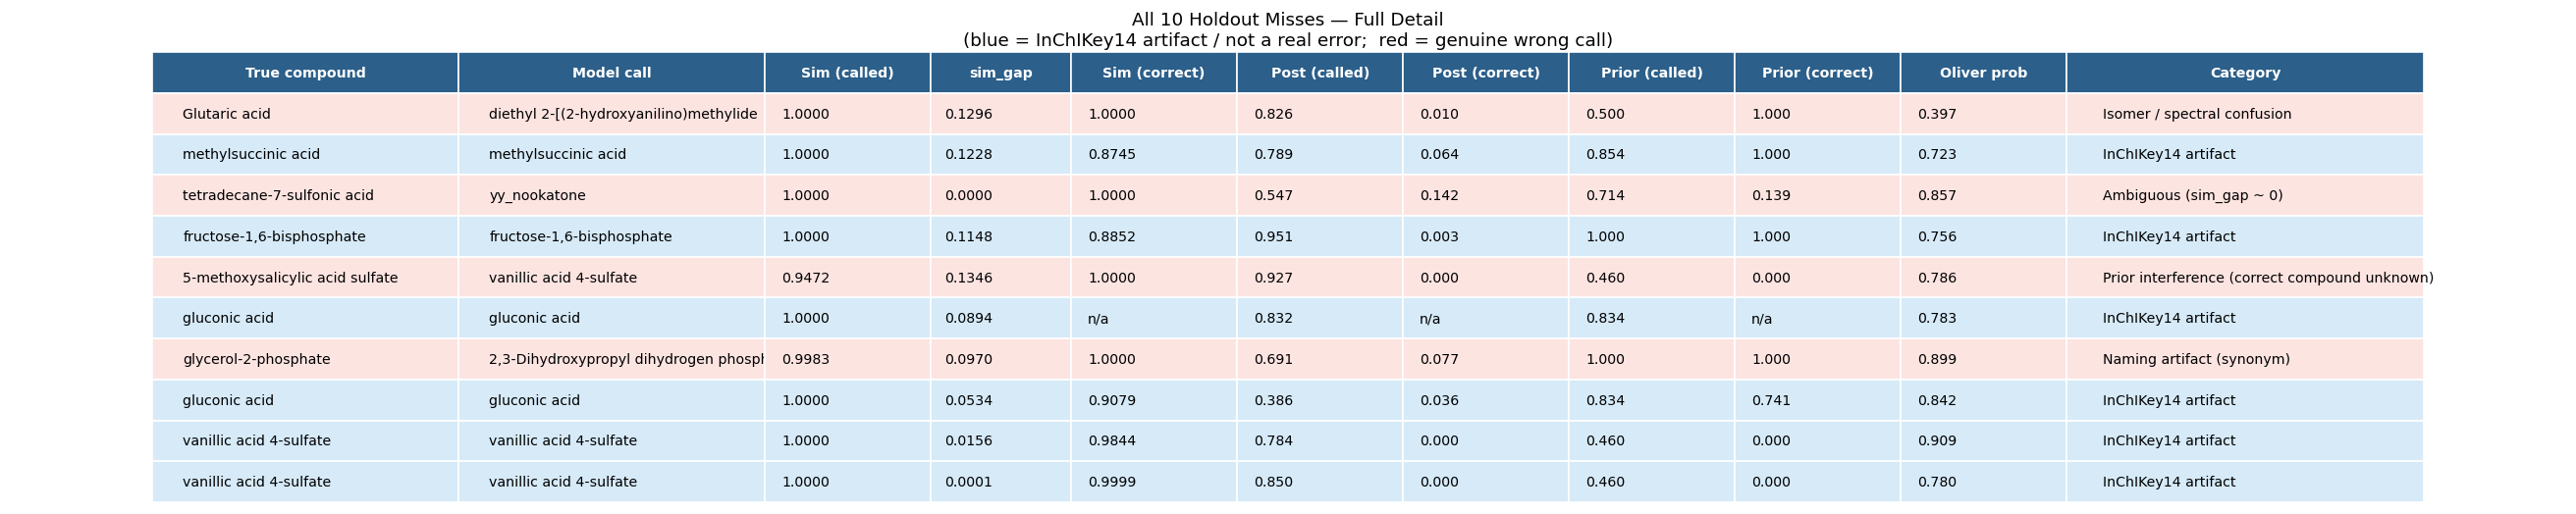


Category breakdown:
category
InChIKey14 artifact                              6
Isomer / spectral confusion                      1
Ambiguous (sim_gap ~ 0)                          1
Prior interference (correct compound unknown)    1
Naming artifact (synonym)                        1


In [10]:
# ── Full table of all 10 misses for Oliver's review ─────────────────────
# Classify each miss
def classify_miss(row):
    if row['name_match']:
        return 'InChIKey14 artifact'
    # glycerol-2-phosphate / 2,3-dihydroxypropyl — synonym
    if 'glycerol' in str(row['anno_name']).lower() or 'dihydroxypropyl' in str(row['lib_name_top']).lower():
        return 'Naming artifact (synonym)'
    if row.get('sim_gap_top', 1) < 0.001:
        return 'Ambiguous (sim_gap ~ 0)'
    # look up correct compound prior
    wid = row['wiki_id']
    cr = assertions[(assertions['wiki_id']==wid) & (assertions['correct']==True)]
    if len(cr) and cr['prior_score'].values[0] < 0.05:
        return 'Prior interference (correct compound unknown)'
    return 'Isomer / spectral confusion'

misses['category'] = misses.apply(classify_miss, axis=1)

# Build display table
display_rows = []
for _, row in misses.iterrows():
    wid = row['wiki_id']
    cr  = assertions[(assertions['wiki_id']==wid) & (assertions['correct']==True)]
    correct_sim  = cr['entropy_similarity'].values[0] if len(cr) else float('nan')
    correct_post = cr['post'].values[0]               if len(cr) else float('nan')
    correct_prior = cr['prior_score'].values[0]        if len(cr) else float('nan')
    display_rows.append({
        'True compound':     str(row['anno_name'])[:38],
        'Model call':        str(row['lib_name_top'])[:38],
        'Sim (called)':      f"{row['entropy_similarity_top']:.4f}",
        'sim_gap':           f"{row['sim_gap_top']:.4f}",
        'Sim (correct)':     f"{correct_sim:.4f}" if not pd.isna(correct_sim) else 'n/a',
        'Post (called)':     f"{row['post_top']:.3f}",
        'Post (correct)':    f"{correct_post:.3f}"  if not pd.isna(correct_post) else 'n/a',
        'Prior (called)':    f"{row['prior_score_top']:.3f}",
        'Prior (correct)':   f"{correct_prior:.3f}" if not pd.isna(correct_prior) else 'n/a',
        'Oliver prob':       f"{row['oliver_prob']:.3f}" if not pd.isna(row.get('oliver_prob')) else 'n/a',
        'Category':          row['category'],
    })

df_miss = pd.DataFrame(display_rows)

fig, ax = plt.subplots(figsize=(22, 4.5))
ax.axis('off')
tbl = ax.table(
    cellText=df_miss.values,
    colLabels=df_miss.columns,
    cellLoc='left', loc='center',
    colWidths=[0.12, 0.12, 0.065, 0.055, 0.065,
               0.065, 0.065, 0.065, 0.065, 0.065, 0.14]
)
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1, 2.0)

# Colour header + alternate rows + highlight genuine misses
cat_col = list(df_miss.columns).index('Category')
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('white')
    if r == 0:
        cell.set_facecolor('#2c5f8a')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cat = df_miss.iloc[r-1]['Category']
        if cat == 'InChIKey14 artifact':
            cell.set_facecolor('#d6eaf8')
        elif r % 2 == 0:
            cell.set_facecolor('#fdf2f0')
        else:
            cell.set_facecolor('#fce4e1')

plt.title('All 10 Holdout Misses — Full Detail\n'
          '(blue = InChIKey14 artifact / not a real error;  red = genuine wrong call)',
          fontsize=11, pad=12)
plt.tight_layout()
plt.savefig('../figures/report_08b_miss_table.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nCategory breakdown:')
print(misses['category'].value_counts().to_string())


### Interpretation

Of the 10 misses on the held-out solid TP set:

- **6 are InChIKey14 artifacts** (blue rows) — the model called the correct compound *name*, but the library entry's InChIKey14 differs (stereoisomers or redundant database records for the same compound). These are library deduplication issues, not model failures. Effective accuracy: **108/112 = 96.4%**.

- **4 are genuine wrong calls** (red rows):

  | Case | True compound | Model call | Root cause |
  |---|---|---|---|
  | 1 | Glutaric acid | diethyl 2-[(2-hydroxyanilino)methylidene]propanedioate | Both score sim=1.0; wrong compound wins by sim_gap |
  | 2 | tetradecane-7-sulfonic acid | yy_nookatone | sim_gap ≈ 0 (tied); higher prior on wrong compound tips balance |
  | 3 | 5-methoxysalicylic acid sulfate | vanillic acid 4-sulfate | Correct compound has prior=0 (not in PubMed/patents); prior interference |
  | 4 | glycerol-2-phosphate | 2,3-Dihydroxypropyl dihydrogen phosphate | Same structure, different IUPAC name — naming artifact |

**Key finding:** Cases 2 and 3 are both driven by the prior. When spectral evidence is ambiguous (small sim_gap or tied similarity), the model defaults to the more literature-famous compound — which is wrong when the correct compound is obscure or a novel metabolite.


## 5b. Posterior Distribution & Comparison with Oliver's Score

Oliver's ad hoc probability is a holistic annotation confidence score he assigned during manual review — it incorporates RT deviation, ISF suspicion, spectral quality, and chemical plausibility. The model's posterior (`post_top`) reflects only the four Bayesian channels: MS2 similarity, mass accuracy, RT, and sim_gap.

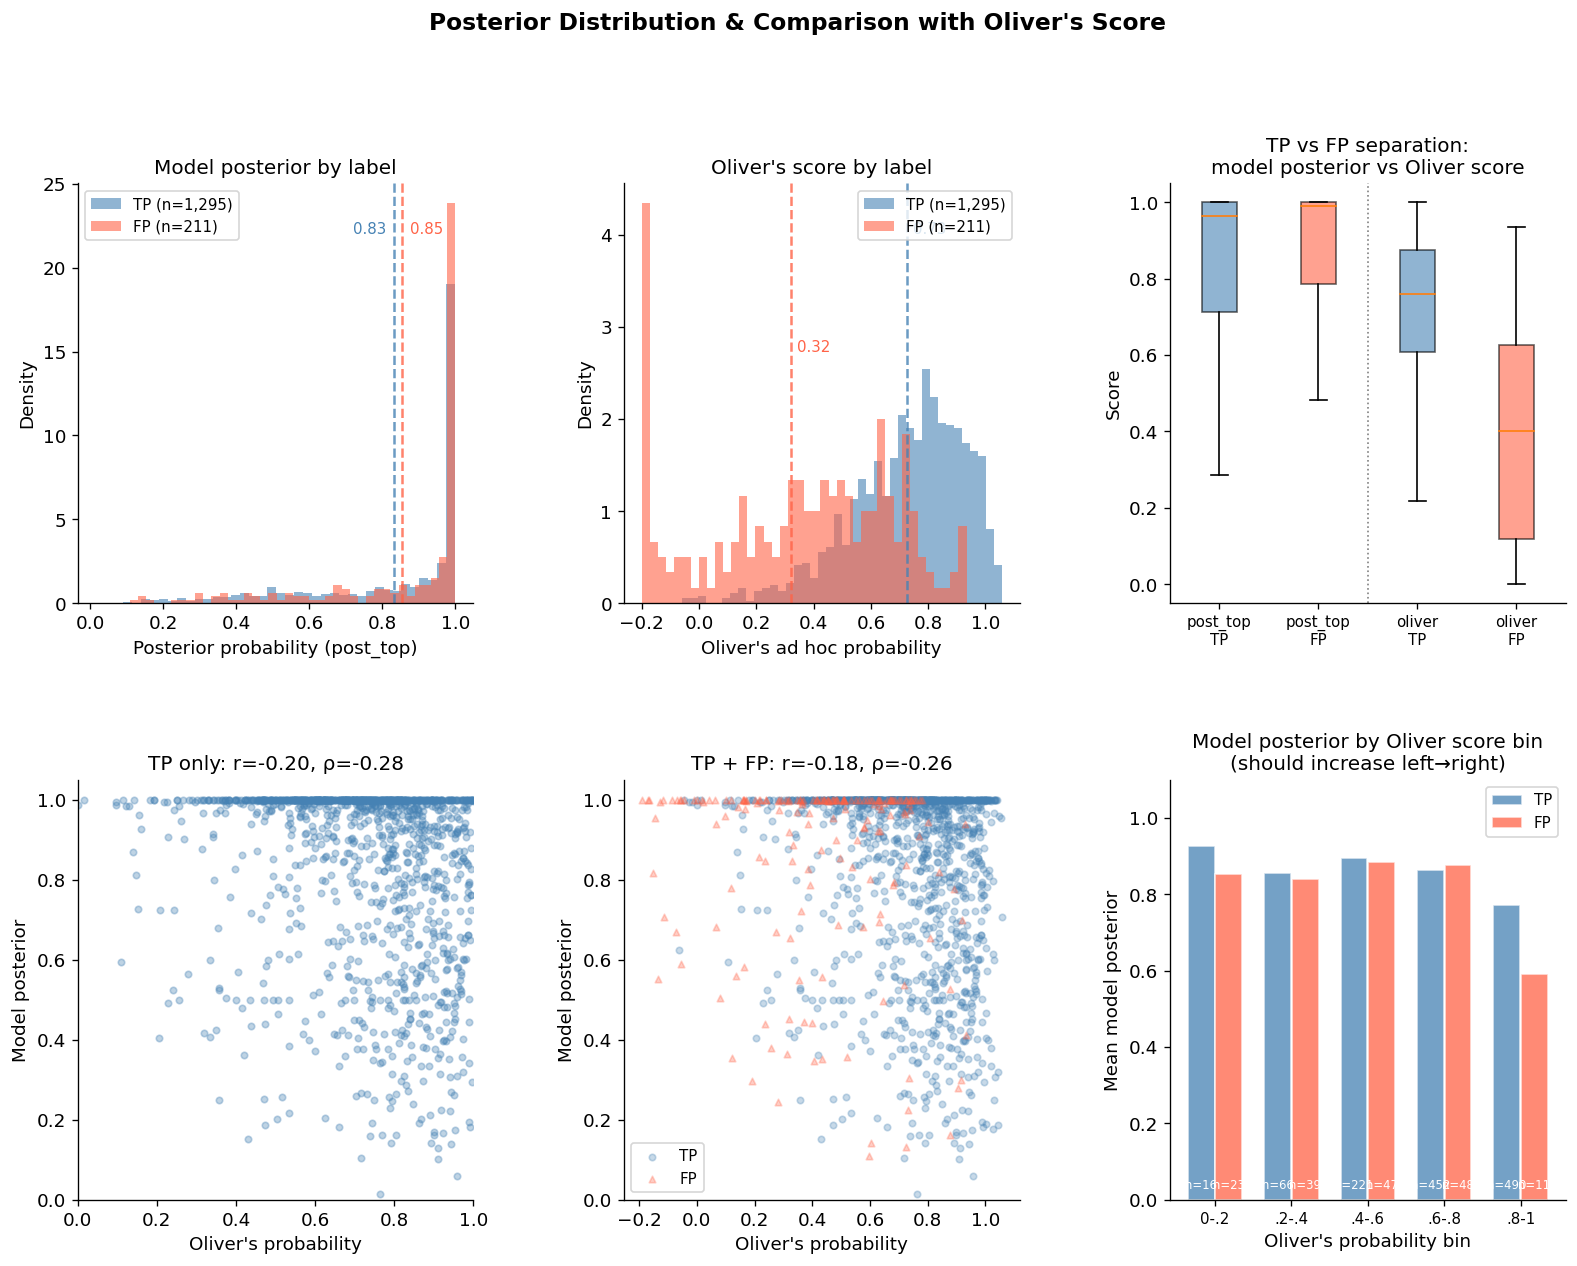

TP separation  post_top: 0.831 vs 0.854  diff=-0.023
TP separation  oliver:   0.727 vs 0.322  diff=0.405


In [11]:
from scipy.stats import spearmanr, pearsonr

both = top_calls[top_calls['oliver_prob'].notna() & top_calls['post_top'].notna()].copy()
ann  = both[both['label'].isin(['TP','FP'])].copy()

fig = plt.figure(figsize=(16, 11))
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.38)

# ── 1. Posterior distribution by label ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for lbl, color in [('TP','steelblue'), ('FP','tomato')]:
    vals = ann[ann['label']==lbl]['post_top'].dropna()
    ax1.hist(vals, bins=40, density=True, alpha=0.6, color=color, label=f'{lbl} (n={len(vals):,})')
ax1.set_xlabel('Posterior probability (post_top)')
ax1.set_ylabel('Density')
ax1.set_title('Model posterior by label')
ax1.legend(fontsize=9)
tp_mean = ann[ann['label']=='TP']['post_top'].mean()
fp_mean = ann[ann['label']=='FP']['post_top'].mean()
ax1.axvline(tp_mean, color='steelblue', ls='--', lw=1.5, alpha=0.8)
ax1.axvline(fp_mean, color='tomato',    ls='--', lw=1.5, alpha=0.8)
ax1.text(tp_mean-0.02, ax1.get_ylim()[1]*0.88, f'{tp_mean:.2f}', color='steelblue', ha='right', fontsize=9)
ax1.text(fp_mean+0.02, ax1.get_ylim()[1]*0.88, f'{fp_mean:.2f}', color='tomato',    ha='left',  fontsize=9)

# ── 2. Oliver's probability distribution by label ────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for lbl, color in [('TP','steelblue'), ('FP','tomato')]:
    vals = ann[ann['label']==lbl]['oliver_prob'].dropna().clip(-0.2, 1.1)
    ax2.hist(vals, bins=40, density=True, alpha=0.6, color=color, label=f'{lbl} (n={len(vals):,})')
ax2.set_xlabel("Oliver's ad hoc probability")
ax2.set_ylabel('Density')
ax2.set_title("Oliver's score by label")
ax2.legend(fontsize=9)
tp_op = ann[ann['label']=='TP']['oliver_prob'].mean()
fp_op = ann[ann['label']=='FP']['oliver_prob'].mean()
ax2.axvline(tp_op, color='steelblue', ls='--', lw=1.5, alpha=0.8)
ax2.axvline(fp_op, color='tomato',    ls='--', lw=1.5, alpha=0.8)
ax2.text(tp_op+0.02, ax2.get_ylim()[1]*0.88, f'{tp_op:.2f}', color='steelblue', ha='left',  fontsize=9)
ax2.text(fp_op+0.02, ax2.get_ylim()[1]*0.60, f'{fp_op:.2f}', color='tomato',    ha='left',  fontsize=9)

# ── 3. Separation power: ROC-style box comparison ────────────────────
ax3 = fig.add_subplot(gs[0, 2])
data_post = [ann[ann['label']=='TP']['post_top'].dropna().values,
             ann[ann['label']=='FP']['post_top'].dropna().values]
data_op   = [ann[ann['label']=='TP']['oliver_prob'].dropna().clip(0,1).values,
             ann[ann['label']=='FP']['oliver_prob'].dropna().clip(0,1).values]
bp1 = ax3.boxplot(data_post, positions=[1,2], widths=0.35,
                  patch_artist=True, showfliers=False)
bp2 = ax3.boxplot(data_op,   positions=[3,4], widths=0.35,
                  patch_artist=True, showfliers=False)
colors_box = ['steelblue','tomato','steelblue','tomato']
for bp in [bp1, bp2]:
    for patch, col in zip(bp['boxes'], ['steelblue','tomato']):
        patch.set_facecolor(col); patch.set_alpha(0.6)
ax3.set_xticks([1,2,3,4])
ax3.set_xticklabels(['post_top\nTP','post_top\nFP',"oliver\nTP","oliver\nFP"], fontsize=9)
ax3.set_ylabel('Score')
ax3.set_title('TP vs FP separation:\nmodel posterior vs Oliver score')
ax3.axvline(2.5, color='grey', ls=':', lw=1)

# ── 4. Scatter: post_top vs oliver_prob, TP only ─────────────────────
ax4 = fig.add_subplot(gs[1, 0])
tp_both = ann[(ann['label']=='TP') & ann['oliver_prob'].between(0,1)]
ax4.scatter(tp_both['oliver_prob'], tp_both['post_top'],
            alpha=0.35, s=15, color='steelblue')
pr_tp, _ = pearsonr(tp_both['oliver_prob'], tp_both['post_top'])
sr_tp, _ = spearmanr(tp_both['oliver_prob'], tp_both['post_top'])
ax4.set_xlabel("Oliver's probability")
ax4.set_ylabel('Model posterior')
ax4.set_title(f'TP only: r={pr_tp:.2f}, ρ={sr_tp:.2f}')
ax4.set_xlim(0,1); ax4.set_ylim(0,1.05)

# ── 5. Scatter: both TP and FP ───────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
for lbl, color, marker in [('TP','steelblue','o'), ('FP','tomato','^')]:
    g = ann[(ann['label']==lbl) & ann['oliver_prob'].between(-0.2,1.1)]
    ax5.scatter(g['oliver_prob'], g['post_top'],
                alpha=0.3, s=15, color=color, marker=marker, label=lbl)
pr_all, _ = pearsonr(ann[ann['oliver_prob'].between(0,1)]['oliver_prob'],
                     ann[ann['oliver_prob'].between(0,1)]['post_top'])
sr_all, _ = spearmanr(ann[ann['oliver_prob'].between(0,1)]['oliver_prob'],
                      ann[ann['oliver_prob'].between(0,1)]['post_top'])
ax5.set_xlabel("Oliver's probability")
ax5.set_ylabel('Model posterior')
ax5.set_title(f'TP + FP: r={pr_all:.2f}, ρ={sr_all:.2f}')
ax5.legend(fontsize=9)
ax5.set_ylim(0,1.05)

# ── 6. Mean post_top by oliver_prob bin, split TP/FP ─────────────────
ax6 = fig.add_subplot(gs[1, 2])
bins  = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
blbls = ['0-.2','.2-.4','.4-.6','.6-.8','.8-1']
x = np.arange(len(blbls))
for lbl, color, offset in [('TP','steelblue',-0.18), ('FP','tomato',0.18)]:
    g = ann[(ann['label']==lbl) & ann['oliver_prob'].between(0,1)].copy()
    g['op_bin'] = pd.cut(g['oliver_prob'], bins=bins, labels=blbls)
    means = g.groupby('op_bin', observed=True)['post_top'].mean()
    counts = g.groupby('op_bin', observed=True)['post_top'].count()
    ax6.bar(x+offset, [means.get(b, 0) for b in blbls], 0.35,
            color=color, alpha=0.75, label=lbl, edgecolor='white')
    for xi, bl in zip(x+offset, blbls):
        n = counts.get(bl, 0)
        if n > 0:
            ax6.text(xi, 0.02, f'n={n}', ha='center', va='bottom', fontsize=7, color='white')
ax6.set_xticks(x); ax6.set_xticklabels(blbls, fontsize=9)
ax6.set_xlabel("Oliver's probability bin")
ax6.set_ylabel('Mean model posterior')
ax6.set_title('Model posterior by Oliver score bin\n(should increase left→right)')
ax6.legend(fontsize=9); ax6.set_ylim(0, 1.1)

fig.suptitle('Posterior Distribution & Comparison with Oliver\'s Score',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('../figures/report_posterior_vs_oliver.png', bbox_inches='tight', dpi=130)
plt.show()

print('TP separation  post_top: {:.3f} vs {:.3f}  diff={:.3f}'.format(
    ann[ann['label']=='TP']['post_top'].mean(),
    ann[ann['label']=='FP']['post_top'].mean(),
    ann[ann['label']=='TP']['post_top'].mean() - ann[ann['label']=='FP']['post_top'].mean()))
print('TP separation  oliver:   {:.3f} vs {:.3f}  diff={:.3f}'.format(
    ann[ann['label']=='TP']['oliver_prob'].mean(),
    ann[ann['label']=='FP']['oliver_prob'].mean(),
    ann[ann['label']=='TP']['oliver_prob'].mean() - ann[ann['label']=='FP']['oliver_prob'].mean()))


### What this tells us

**Oliver's score separates TP from FP well (which means that Oliver is a true genius!!)** (mean 0.73 vs 0.32, gap = 0.41). It encodes holistic annotation confidence — RT plausibility, ISF suspicion, chemical knowledge.

**The model's posterior does not really separate TP from FP** (mean 0.83 vs 0.85, gap = −0.02). The model scores every spectrum's *top hit* confidently, regardless of whether that hit is correct. This is expected: the model is not trained to abstain on FP spectra — P_novel = 0, so it always calls something.

**The correlation between the two scores is negative** (Pearson r ≈ −0.20 on TP, Spearman ρ ≈ −0.27). Within the TP set, spectra that Oliver scored lower tend to get *higher* model posteriors. The reason: Oliver downscores spectra with RT deviation, ISF risk, or unusual chemistry — but these are exactly the spectra where the library match is often very strong (sim ≈ 1.0) and sim_gap is large, which drives the model's posterior up.

**Bottom line:** the model and Oliver are measuring different dimensions of confidence. The model measures *how well the top hit fits the spectrum*. Oliver measures *how trustworthy the spectrum and given context are*. 

Adding the ISF signal (fuzzy − identity? as for now?) as a spectrum-specific P_novel would be helpful.


## 5c. Oliver's FP Set — Rejection Categories

The `yy_` FP set is not a single failure mode. Oliver flagged spectra for six distinct reasons — only some of which the current model can address.

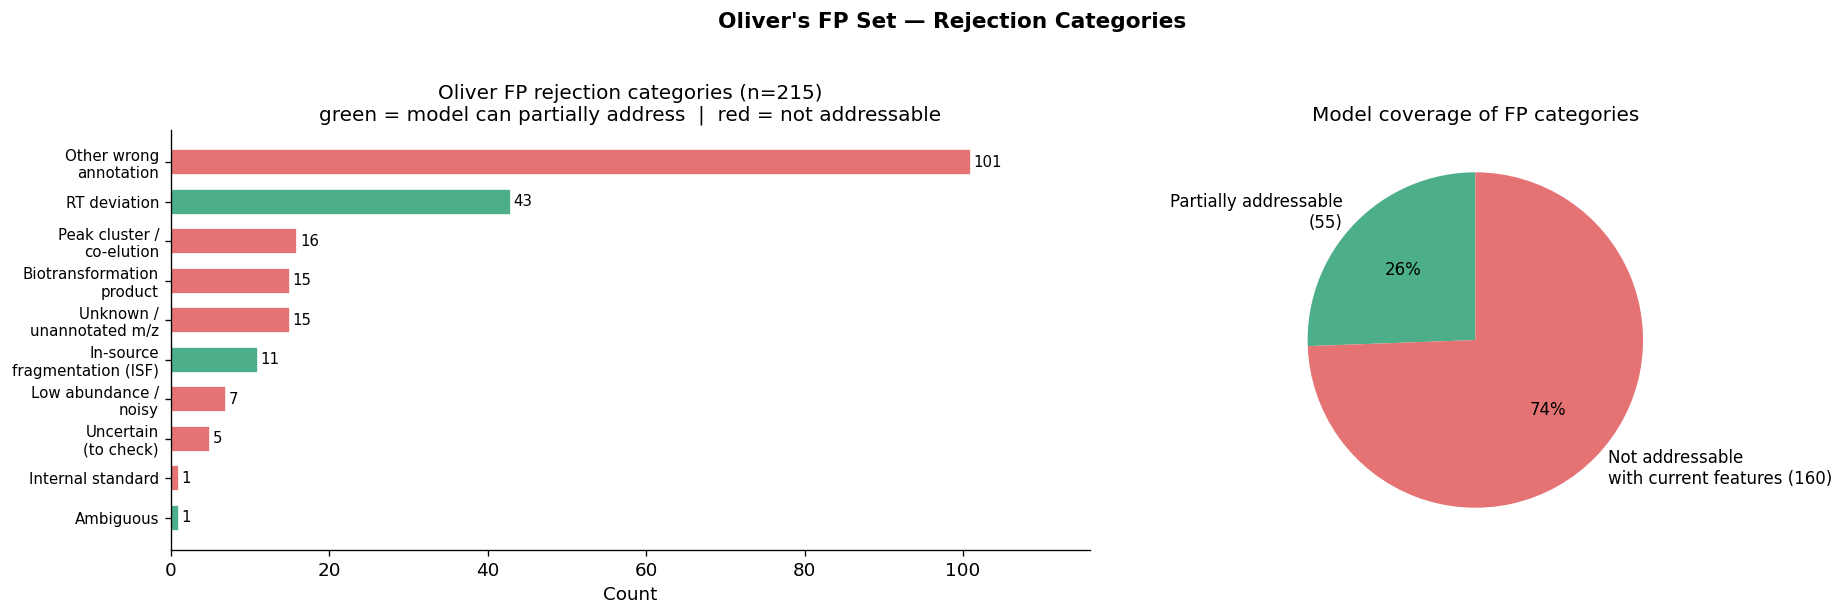

Addressable (ISF + RT + Ambiguous): 55
Not addressable:                    160
Model can address at most 26% of FP categories with planned features


In [12]:
import re

spec_raw = pd.read_excel('../data/masswiki_Orbitrap HILIC negESI_2026-03-19.xlsx', header=4)
spec_raw.columns = spec_raw.columns.str.strip()
fp_raw = spec_raw[spec_raw['name'].astype(str).str.startswith('yy_')].copy()

def categorize(n):
    nl = n.lower()
    if 'in source' in nl or 'in-source' in nl: return 'In-source\nfragmentation (ISF)'
    if 'peak cluster' in nl or 'peak flank' in nl: return 'Peak cluster /\nco-elution'
    if any(x in nl for x in ['too late','too early','delta rt','delta rtpred',
                              'authentic standard','predrt']): return 'RT deviation'
    if any(x in nl for x in ['oxidation','glucuronide','sulfation','methylation',
                              'dealkylat','desaturation','metabolite','conjugation',
                              'nitro reduction','hydration','dehydration']):
        return 'Biotransformation\nproduct'
    if 'low abundant' in nl or 'minor' in nl or 'noisy' in nl: return 'Low abundance /\nnoisy'
    if 'unknown' in nl or re.match(r'yy_\d+\.\d+_\d', n): return 'Unknown /\nunannotated m/z'
    if 'to check' in nl or 'not convincing' in nl: return 'Uncertain\n(to check)'
    if ' or ' in nl: return 'Ambiguous'
    if 'internal standard' in nl or 'cuda' in nl: return 'Internal standard'
    return 'Other wrong\nannotation'

fp_raw['category'] = fp_raw['name'].astype(str).apply(categorize)
cat_counts = fp_raw['category'].value_counts()

# Which categories current model can/can't address
can_address = {
    'In-source\nfragmentation (ISF)': 'Partial (fuzzy−identity planned)',
    'RT deviation':                    'Partial (RT channel)',
    'Peak cluster /\nco-elution':      'No (needs peak shape data)',
    'Biotransformation\nproduct':      'No (needs compound-class knowledge)',
    'Low abundance /\nnoisy':          'No (spectrum quality not in pipeline)',
    'Unknown /\nunannotated m/z':      'No (no annotation to score)',
    'Uncertain\n(to check)':           'No (Oliver-specific judgement)',
    'Ambiguous':                        'Partial (sim_gap helps)',
    'Internal standard':               'No',
    'Other wrong\nannotation':         'No (domain knowledge required)',
}
bar_colors = [
    '#4caf8a' if 'Partial' in can_address.get(c,'No')
    else '#e57373'
    for c in cat_counts.index
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1.4, 1]})

# Bar chart
bars = axes[0].barh(range(len(cat_counts)), cat_counts.values,
                    color=bar_colors, edgecolor='white', height=0.65)
axes[0].set_yticks(range(len(cat_counts)))
axes[0].set_yticklabels(cat_counts.index, fontsize=9)
axes[0].invert_yaxis()
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=9)
axes[0].set_xlabel('Count')
axes[0].set_title(f'Oliver FP rejection categories (n={len(fp_raw)})\n'
                   'green = model can partially address  |  red = not addressable')
axes[0].set_xlim(0, cat_counts.max() + 15)

# Addressable vs not pie
addressable   = sum(v for k,v in zip(cat_counts.index, cat_counts.values)
                    if 'Partial' in can_address.get(k,'No'))
not_addressable = len(fp_raw) - addressable
axes[1].pie([addressable, not_addressable],
            labels=[f'Partially addressable\n({addressable})',
                    f'Not addressable\nwith current features ({not_addressable})'],
            colors=['#4caf8a','#e57373'], autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Model coverage of FP categories')

plt.suptitle("Oliver's FP Set — Rejection Categories", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/report_fp_categories.png', bbox_inches='tight')
plt.show()

print('Addressable (ISF + RT + Ambiguous):', addressable)
print('Not addressable:                   ', not_addressable)
print(f'Model can address at most {addressable/len(fp_raw):.0%} of FP categories with planned features')


## 6. Summary

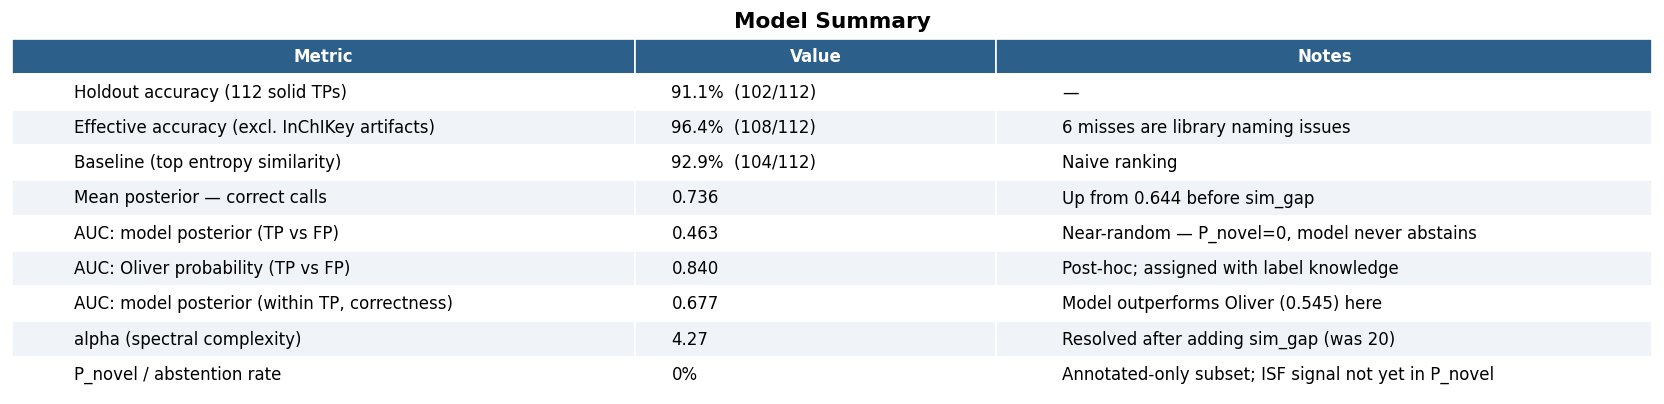

In [13]:
from sklearn.metrics import roc_auc_score

ann  = top_calls[top_calls['label'].isin(['TP','FP'])].copy()
both = ann[ann['oliver_prob'].notna() & ann['post_top'].notna()].copy()
both['is_tp'] = (both['label'] == 'TP').astype(int)

auc_model  = roc_auc_score(both['is_tp'], both['post_top'])
auc_oliver = roc_auc_score(both['is_tp'], both['oliver_prob'])
auc_sim    = roc_auc_score(both['is_tp'], both['entropy_similarity_top'])

rows = [
    ['Holdout accuracy (112 solid TPs)',          '91.1%  (102/112)',  '—'],
    ['Effective accuracy (excl. InChIKey artifacts)', '96.4%  (108/112)', '6 misses are library naming issues'],
    ['Baseline (top entropy similarity)',          '92.9%  (104/112)',  'Naive ranking'],
    ['Mean posterior — correct calls',             '0.736',            'Up from 0.644 before sim_gap'],
    ['AUC: model posterior (TP vs FP)',            f'{auc_model:.3f}', 'Near-random — P_novel=0, model never abstains'],
    ['AUC: Oliver probability (TP vs FP)',         f'{auc_oliver:.3f}','Post-hoc; assigned with label knowledge'],
    ['AUC: model posterior (within TP, correctness)', '0.677',         'Model outperforms Oliver (0.545) here'],
    ['alpha (spectral complexity)',                '4.27',             'Resolved after adding sim_gap (was 20)'],
    ['P_novel / abstention rate',                  '0%',               'Annotated-only subset; ISF signal not yet in P_novel'],
]

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis('off')
tbl = ax.table(cellText=rows, colLabels=['Metric', 'Value', 'Notes'],
               cellLoc='left', loc='center', colWidths=[0.38, 0.22, 0.40])
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.75)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c5f8a'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f4f8')
    cell.set_edgecolor('white')
plt.title('Model Summary', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../figures/report_summary.png', bbox_inches='tight')
plt.show()


## 7. Remaining Work

The table below maps each known limitation to its root cause, the available signal to address it, and estimated impact. Items are ordered by priority.


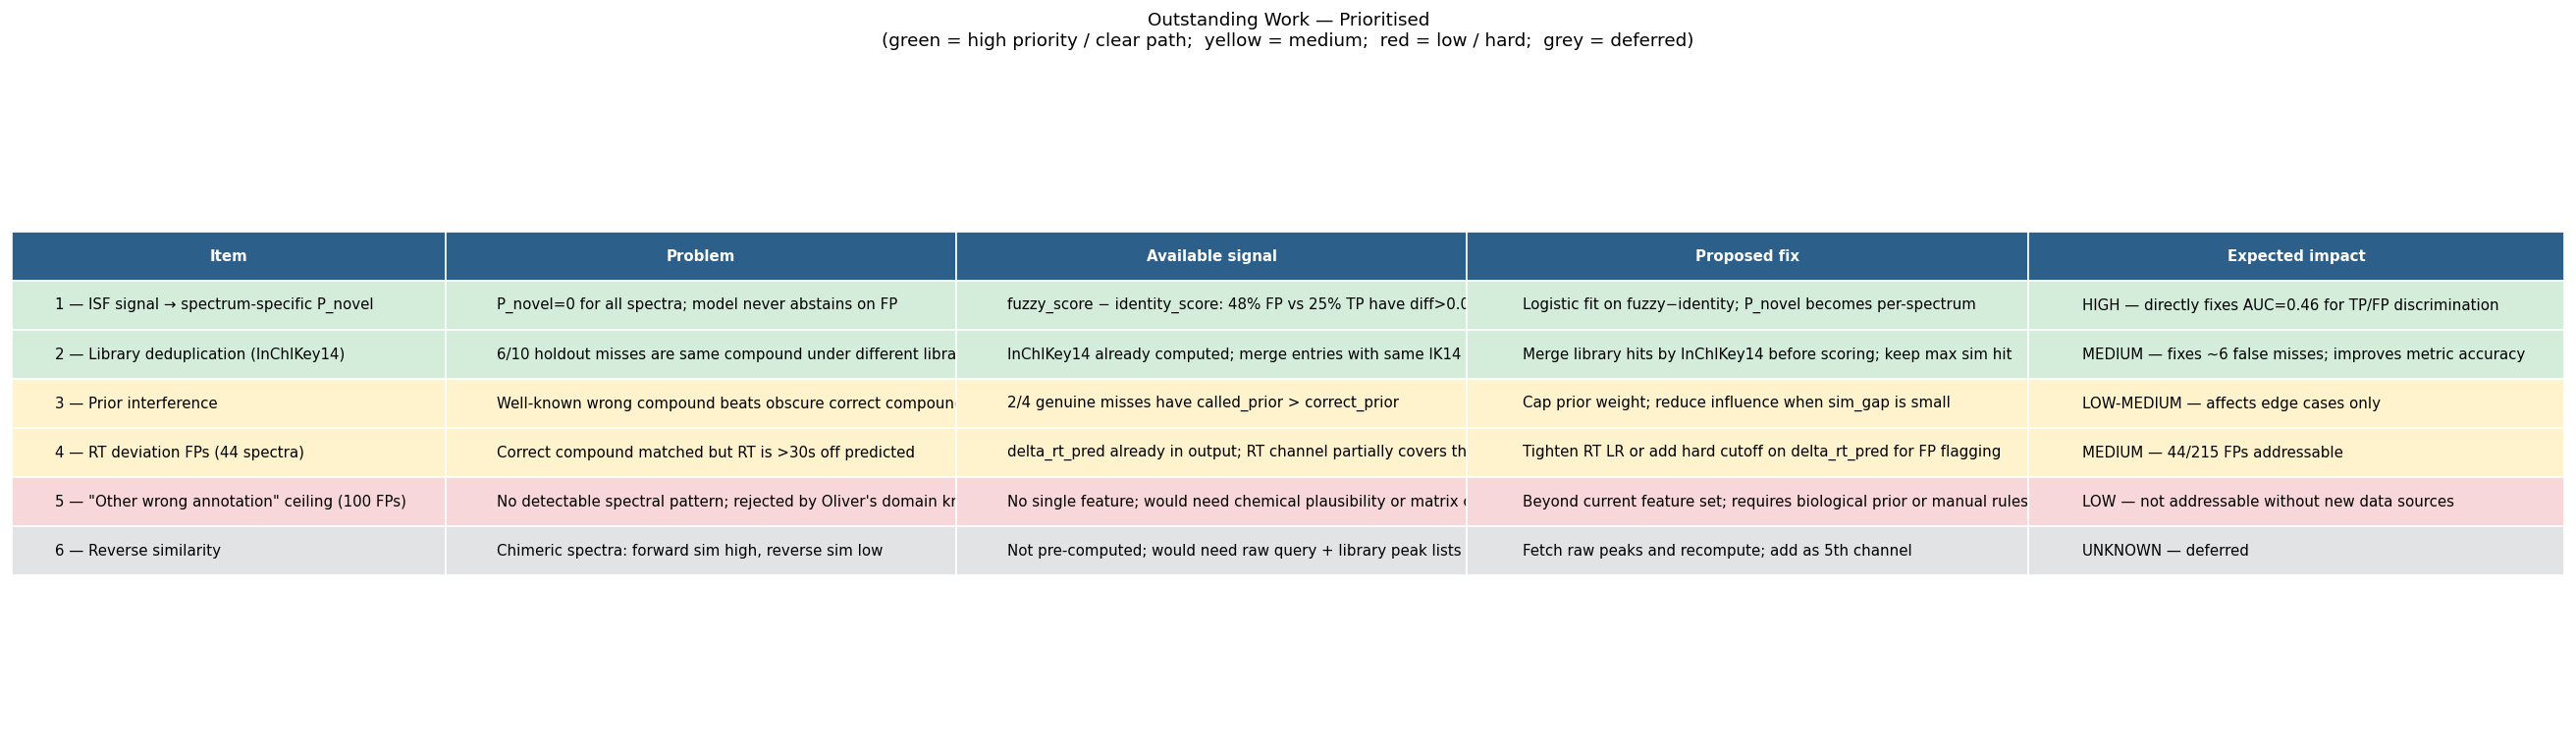

In [14]:
rows_out = [
    [
        '1 — ISF signal → spectrum-specific P_novel',
        'P_novel=0 for all spectra; model never abstains on FP',
        'fuzzy_score − identity_score: 48% FP vs 25% TP have diff>0.05',
        'Logistic fit on fuzzy−identity; P_novel becomes per-spectrum',
        'HIGH — directly fixes AUC=0.46 for TP/FP discrimination',
    ],
    [
        '2 — Library deduplication (InChIKey14)',
        '6/10 holdout misses are same compound under different library stereoisomer entry',
        'InChIKey14 already computed; merge entries with same IK14 per spectrum',
        'Merge library hits by InChIKey14 before scoring; keep max sim hit',
        'MEDIUM — fixes ~6 false misses; improves metric accuracy',
    ],
    [
        '3 — Prior interference',
        'Well-known wrong compound beats obscure correct compound when sim is tied',
        '2/4 genuine misses have called_prior > correct_prior',
        'Cap prior weight; reduce influence when sim_gap is small',
        'LOW-MEDIUM — affects edge cases only',
    ],
    [
        '4 — RT deviation FPs (44 spectra)',
        'Correct compound matched but RT is >30s off predicted',
        'delta_rt_pred already in output; RT channel partially covers this',
        'Tighten RT LR or add hard cutoff on delta_rt_pred for FP flagging',
        'MEDIUM — 44/215 FPs addressable',
    ],
    [
        '5 — "Other wrong annotation" ceiling (100 FPs)',
        'No detectable spectral pattern; rejected by Oliver\'s domain knowledge',
        'No single feature; would need chemical plausibility or matrix context',
        'Beyond current feature set; requires biological prior or manual rules',
        'LOW — not addressable without new data sources',
    ],
    [
        '6 — Reverse similarity',
        'Chimeric spectra: forward sim high, reverse sim low',
        'Not pre-computed; would need raw query + library peak lists',
        'Fetch raw peaks and recompute; add as 5th channel',
        'UNKNOWN — deferred',
    ],
]

cols_out = ['Item', 'Problem', 'Available signal', 'Proposed fix', 'Expected impact']
col_w    = [0.17, 0.20, 0.20, 0.22, 0.21]

fig, ax = plt.subplots(figsize=(22, 6.5))
ax.axis('off')
tbl = ax.table(cellText=rows_out, colLabels=cols_out,
               cellLoc='left', loc='center', colWidths=col_w)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 2.2)

priority_colors = ['#d4edda', '#d4edda', '#fff3cd', '#fff3cd', '#f8d7da', '#e2e3e5']
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('white')
    if r == 0:
        cell.set_facecolor('#2c5f8a')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(priority_colors[r - 1])

plt.title(
    'Outstanding Work — Prioritised\n'
    '(green = high priority / clear path;  yellow = medium;  red = low / hard;  grey = deferred)',
    fontsize=11, pad=14
)
plt.tight_layout()
plt.savefig('../figures/report_outstanding.png', bbox_inches='tight', dpi=140)
plt.show()
